<a href="https://colab.research.google.com/github/mt508/machine-learning-/blob/main/ecg_perdiction_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
data=files.upload()

Saving ecg_dataset.zip to ecg_dataset.zip


In [2]:
!unzip ecg_dataset.zip

Archive:  ecg_dataset.zip
   creating: ecg_dataset/
   creating: ecg_dataset/Abnormal heartbeat/
  inflating: ecg_dataset/Abnormal heartbeat/HB_(1).png  
  inflating: ecg_dataset/Abnormal heartbeat/HB_(10).png  
  inflating: ecg_dataset/Abnormal heartbeat/HB_(100).png  
  inflating: ecg_dataset/Abnormal heartbeat/HB_(101).png  
  inflating: ecg_dataset/Abnormal heartbeat/HB_(102).png  
  inflating: ecg_dataset/Abnormal heartbeat/HB_(103).png  
  inflating: ecg_dataset/Abnormal heartbeat/HB_(104).png  
  inflating: ecg_dataset/Abnormal heartbeat/HB_(105).png  
  inflating: ecg_dataset/Abnormal heartbeat/HB_(106).png  
  inflating: ecg_dataset/Abnormal heartbeat/HB_(107).png  
  inflating: ecg_dataset/Abnormal heartbeat/HB_(108).png  
  inflating: ecg_dataset/Abnormal heartbeat/HB_(109).png  
  inflating: ecg_dataset/Abnormal heartbeat/HB_(11).png  
  inflating: ecg_dataset/Abnormal heartbeat/HB_(110).png  
  inflating: ecg_dataset/Abnormal heartbeat/HB_(111).png  
  inflating: ecg_datas

In [3]:
import os
import shutil
import random
from sklearn.model_selection import StratifiedShuffleSplit


In [4]:
dataset_dir = "/content/ecg_dataset"
classes = os.listdir(dataset_dir)

image_paths = []
labels = []

for label_idx, class_name in enumerate(classes):
    class_dir = os.path.join(dataset_dir, class_name)
    for img in os.listdir(class_dir):
        if img.lower().endswith((".png", ".jpg", ".jpeg")):
            image_paths.append(os.path.join(class_dir, img))
            labels.append(label_idx)


In [9]:
sss1 = StratifiedShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

for train_idx, temp_idx in sss1.split(image_paths, labels):
    train_paths = [image_paths[i] for i in train_idx]
    train_labels = [labels[i] for i in train_idx]

    temp_paths = [image_paths[i] for i in temp_idx]
    temp_labels = [labels[i] for i in temp_idx]


In [11]:
sss2 = StratifiedShuffleSplit(
    n_splits=1,
    test_size=0.50,
    random_state=42
)

for val_idx, test_idx in sss2.split(temp_paths, temp_labels):
    val_paths = [temp_paths[i] for i in val_idx]
    test_paths = [temp_paths[i] for i in test_idx]


In [12]:
output_dir = "ecg_split"

splits = ["train", "val", "test"]

for split in splits:
    for class_name in classes:
        os.makedirs(os.path.join(output_dir, split, class_name), exist_ok=True)


In [13]:
def copy_images(image_list, split_name):
    for img_path in image_list:
        class_name = os.path.basename(os.path.dirname(img_path))
        dest = os.path.join(output_dir, split_name, class_name)
        shutil.copy(img_path, dest)

copy_images(train_paths, "train")
copy_images(val_paths, "val")
copy_images(test_paths, "test")


In [18]:
from collections import Counter

print("Train:", Counter(train_labels))
print("Val  :", Counter([labels[image_paths.index(p)] for p in val_paths]))
print("Test :", Counter([labels[image_paths.index(p)] for p in test_paths]))


Train: Counter({2: 236, 0: 192, 1: 137})
Val  : Counter({2: 30, 0: 24, 1: 17})
Test : Counter({2: 29, 0: 25, 1: 17})


In [29]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

IMG_SIZE = 224
BATCH_SIZE = 16

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(3),
    transforms.ToTensor()
])

val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

train_ds = datasets.ImageFolder("/content/ecg_split/train", transform=train_tfms)
val_ds   = datasets.ImageFolder("/content/ecg_split/val", transform=val_tfms)
test_ds  = datasets.ImageFolder("/content/ecg_split/test", transform=val_tfms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)


resnet

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from tqdm import tqdm


In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [22]:
# train_loader, val_loader already defined
num_classes = 3


In [23]:
model = models.resnet18(pretrained=True)

# Replace final FC layer
model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 97.7MB/s]


In [24]:
import numpy as np

# From your Train Counter
class_counts = np.array([192, 137, 236])  # [Abnormal, MI, Normal]

class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum()

weights = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)


In [25]:
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=3, factor=0.3
)


In [26]:
def train_one_epoch(model, loader):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, leave=False):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / len(loader), correct / total


In [27]:
def validate(model, loader):
    model.eval()
    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / len(loader), correct / total


In [28]:
EPOCHS = 20
best_val_acc = 0

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc = validate(model, val_loader)

    scheduler.step(val_loss)

    print(f"Epoch [{epoch+1}/{EPOCHS}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
    print("-" * 50)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "resnet18_ecg_best.pth")


Epoch [1/20]
Train Loss: 0.6144 | Train Acc: 0.7186
Val   Loss: 1.1870 | Val   Acc: 0.5352
--------------------------------------------------


Epoch [2/20]
Train Loss: 0.2742 | Train Acc: 0.9080
Val   Loss: 0.8371 | Val   Acc: 0.6761
--------------------------------------------------


Epoch [3/20]
Train Loss: 0.1967 | Train Acc: 0.9274
Val   Loss: 0.1872 | Val   Acc: 0.9014
--------------------------------------------------


Epoch [4/20]
Train Loss: 0.1106 | Train Acc: 0.9611
Val   Loss: 0.0692 | Val   Acc: 0.9859
--------------------------------------------------


Epoch [5/20]
Train Loss: 0.0904 | Train Acc: 0.9593
Val   Loss: 0.1095 | Val   Acc: 0.9718
--------------------------------------------------


...

Epoch [16/20]
Train Loss: 0.0082 | Train Acc: 1.0000
Val   Loss: 0.0170 | Val   Acc: 0.9859
--------------------------------------------------


Epoch [17/20]
Train Loss: 0.0413 | Train Acc: 0.9947
Val   Loss: 0.0149 | Val   Acc: 1.0000
--------------------------------------------------


Epoch [18/20]
Train Loss: 0.0250 | Train Acc: 0.9947
Val   Loss: 0.0144 | Val   Acc: 0.9859
--------------------------------------------------


Epoch [19/20]
Train Loss: 0.0171 | Train Acc: 0.9929
Val   Loss: 0.0436 | Val   Acc: 0.9718
--------------------------------------------------


Epoch [20/20]
Train Loss: 0.0138 | Train Acc: 0.9982
Val   Loss: 0.0364 | Val   Acc: 0.9718
--------------------------------------------------


In [30]:
torch.save(model.state_dict(), "resnet18_ecg_best.pth")


In [31]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_accuracy = correct / total
print(f"Test Accuracy: {test_accuracy:.4f}")


Test Accuracy: 1.0000


In [32]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(
    all_labels,
    all_preds,
    target_names=["Abnormal", "History_of_MI", "Normal"]
))


Confusion Matrix:
 [[25  0  0]
 [ 0 17  0]
 [ 0  0 29]]

Classification Report:

               precision    recall  f1-score   support

     Abnormal       1.00      1.00      1.00        25
History_of_MI       1.00      1.00      1.00        17
       Normal       1.00      1.00      1.00        29

     accuracy                           1.00        71
    macro avg       1.00      1.00      1.00        71
 weighted avg       1.00      1.00      1.00        71



In [33]:
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score

all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = F.softmax(outputs, dim=1).cpu().numpy()
        all_probs.extend(probs)

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

roc_auc = roc_auc_score(
    all_labels,
    all_probs,
    multi_class="ovr"
)

print(f"ROC-AUC (OvR): {roc_auc:.4f}")


ROC-AUC (OvR): 1.0000


In [34]:
print(test_loader.dataset.root)


/content/ecg_split/test


In [35]:
roc_auc_score(all_labels, all_probs, multi_class="ovr")


np.float64(1.0)

In [36]:
print(all_probs.shape)
print(all_probs[:5])
print(all_labels[:5])


(71, 3)
[[9.9849331e-01 1.5030900e-03 3.5438295e-06]
 [9.9998879e-01 1.1258985e-05 3.5202483e-08]
 [9.9952984e-01 4.4297852e-04 2.7167223e-05]
 [9.9999523e-01 4.7345902e-06 2.6158487e-08]
 [9.9999523e-01 4.7345902e-06 2.6158487e-08]]
[0 0 0 0 0]


tiny vit

In [37]:
!pip install timm


In [38]:
import torch
import torch.nn as nn
import torch.optim as optim
import timm
from tqdm import tqdm
import numpy as np


In [39]:
model = timm.create_model(
    "tiny_vit_21m_224",
    pretrained=True,
    num_classes=num_classes
)

model = model.to(device)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/133M [00:00<?, ?B/s]

In [40]:
# From your Train Counter
class_counts = np.array([192, 137, 236])  # [Abnormal, MI, Normal]

class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum()

weights = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)


In [41]:
optimizer = optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=20
)


In [42]:
def train_one_epoch(model, loader):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, leave=False):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / len(loader), correct / total


In [43]:
def validate(model, loader):
    model.eval()
    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / len(loader), correct / total


In [44]:
EPOCHS = 20
best_val_acc = 0

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc = validate(model, val_loader)

    scheduler.step()

    print(f"Epoch [{epoch+1}/{EPOCHS}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
    print("-" * 50)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "tinyvit_ecg_best.pth")


Epoch [1/20]
Train Loss: 0.7159 | Train Acc: 0.6655
Val   Loss: 0.5128 | Val   Acc: 0.8451
--------------------------------------------------


Epoch [2/20]
Train Loss: 0.3681 | Train Acc: 0.8602
Val   Loss: 0.2777 | Val   Acc: 0.9296
--------------------------------------------------


Epoch [3/20]
Train Loss: 0.2597 | Train Acc: 0.9115
Val   Loss: 0.4076 | Val   Acc: 0.8592
--------------------------------------------------


Epoch [4/20]
Train Loss: 0.2002 | Train Acc: 0.9274
Val   Loss: 0.1979 | Val   Acc: 0.9155
--------------------------------------------------


Epoch [5/20]
Train Loss: 0.1900 | Train Acc: 0.9310
Val   Loss: 0.2114 | Val   Acc: 0.8873
--------------------------------------------------


...

Epoch [16/20]
Train Loss: 0.0288 | Train Acc: 0.9876
Val   Loss: 0.0644 | Val   Acc: 0.9577
--------------------------------------------------


Epoch [17/20]
Train Loss: 0.0284 | Train Acc: 0.9965
Val   Loss: 0.0222 | Val   Acc: 0.9859
--------------------------------------------------


Epoch [18/20]
Train Loss: 0.0298 | Train Acc: 0.9929
Val   Loss: 0.0148 | Val   Acc: 0.9859
--------------------------------------------------


Epoch [19/20]
Train Loss: 0.0257 | Train Acc: 0.9929
Val   Loss: 0.0469 | Val   Acc: 0.9718
--------------------------------------------------


Epoch [20/20]
Train Loss: 0.0265 | Train Acc: 0.9947
Val   Loss: 0.0270 | Val   Acc: 0.9859
--------------------------------------------------


In [45]:
model.load_state_dict(torch.load("tinyvit_ecg_best.pth"))
model.eval()


TinyVit(
  (patch_embed): PatchEmbed(
    (conv1): ConvNorm(
      (conv): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (act): GELU(approximate='none')
    (conv2): ConvNorm(
      (conv): Conv2d(48, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (stages): Sequential(
    (0): ConvLayer(
      (blocks): Sequential(
        (0): MBConv(
          (conv1): ConvNorm(
            (conv): Conv2d(96, 384, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (bn): BatchNorm2d(384, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          )
          (act1): GELU(approximate='none')
          (conv2): ConvNorm(
            (conv): Conv2d(384, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=384, bias=Fals

In [46]:
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize

all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        preds = torch.argmax(probs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)


In [49]:
test_acc = accuracy_score(all_labels, all_preds)
print(f"Test Accuracy: {test_acc:.4f}")


Test Accuracy: 1.0000


In [50]:
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)


Confusion Matrix:
[[25  0  0]
 [ 0 17  0]
 [ 0  0 29]]


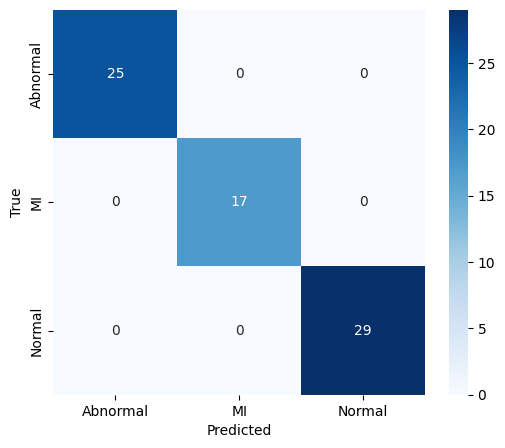

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Abnormal", "MI", "Normal"],
            yticklabels=["Abnormal", "MI", "Normal"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [52]:
# One-vs-Rest binarization
y_true_bin = label_binarize(all_labels, classes=[0, 1, 2])

roc_auc = roc_auc_score(
    y_true_bin,
    all_probs,
    multi_class="ovr",
    average="macro"
)

print(f"ROC-AUC (OvR): {roc_auc:.4f}")


ROC-AUC (OvR): 1.0000


prediction

In [53]:
from PIL import Image
from torchvision import transforms

img_path = "/content/Screenshot 2026-01-09 004320.png"  # replace with your file
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

img = Image.open(img_path).convert("RGB")
img_tensor = transform(img).unsqueeze(0).to(device)


In [54]:
model.load_state_dict(torch.load("tinyvit_ecg_best.pth"))
model.eval()


TinyVit(
  (patch_embed): PatchEmbed(
    (conv1): ConvNorm(
      (conv): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (act): GELU(approximate='none')
    (conv2): ConvNorm(
      (conv): Conv2d(48, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (stages): Sequential(
    (0): ConvLayer(
      (blocks): Sequential(
        (0): MBConv(
          (conv1): ConvNorm(
            (conv): Conv2d(96, 384, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (bn): BatchNorm2d(384, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          )
          (act1): GELU(approximate='none')
          (conv2): ConvNorm(
            (conv): Conv2d(384, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=384, bias=Fals

In [55]:
with torch.no_grad():
    outputs = model(img_tensor)
    probs = torch.softmax(outputs, dim=1)
    pred = torch.argmax(probs, dim=1).item()

print("Predicted class:", pred)
print("Class probabilities:", probs.cpu().numpy())


Predicted class: 0
Class probabilities: [[0.49715567 0.30492347 0.19792083]]


In [56]:
from torchvision.datasets import ImageFolder

print(train_dataset.class_to_idx)


{'Abnormal heartbeat': 0, 'History of MI': 1, 'Normal Person': 2}
